In [ ]:
pip install pandas scikit-learn pyserial

In [ ]:
from google.colab import files
files.upload()

Saving fault_data.csv to fault_data.csv


{'fault_data.csv': b'temp,current,vibration,fault\r\n45,0.7,0,0\r\n46,0.8,0,0\r\n48,1.0,0,0\r\n60,2.5,1,1\r\n65,3.0,1,1\r\n70,3.5,1,1'}

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
data = pd.read_csv("fault_data.csv")

print(data.head())

   temp  current  vibration  fault
0    45      0.7          0      0
1    46      0.8          0      0
2    48      1.0          0      0
3    60      2.5          1      1
4    65      3.0          1      1


In [ ]:
X = data[['temp', 'current', 'vibration']]
y = data['fault']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


In [ ]:
def predict_fault(temp, current, vibration):
    result = model.predict([[temp, current, vibration]])

    if result[0] == 1:
        return "❌ FAULT DETECTED"
    else:
        return "✅ NORMAL"

print(predict_fault(65, 3.2, 1))
print(predict_fault(45, 0.8, 0))

❌ FAULT DETECTED
✅ NORMAL


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
!pip install pyserial

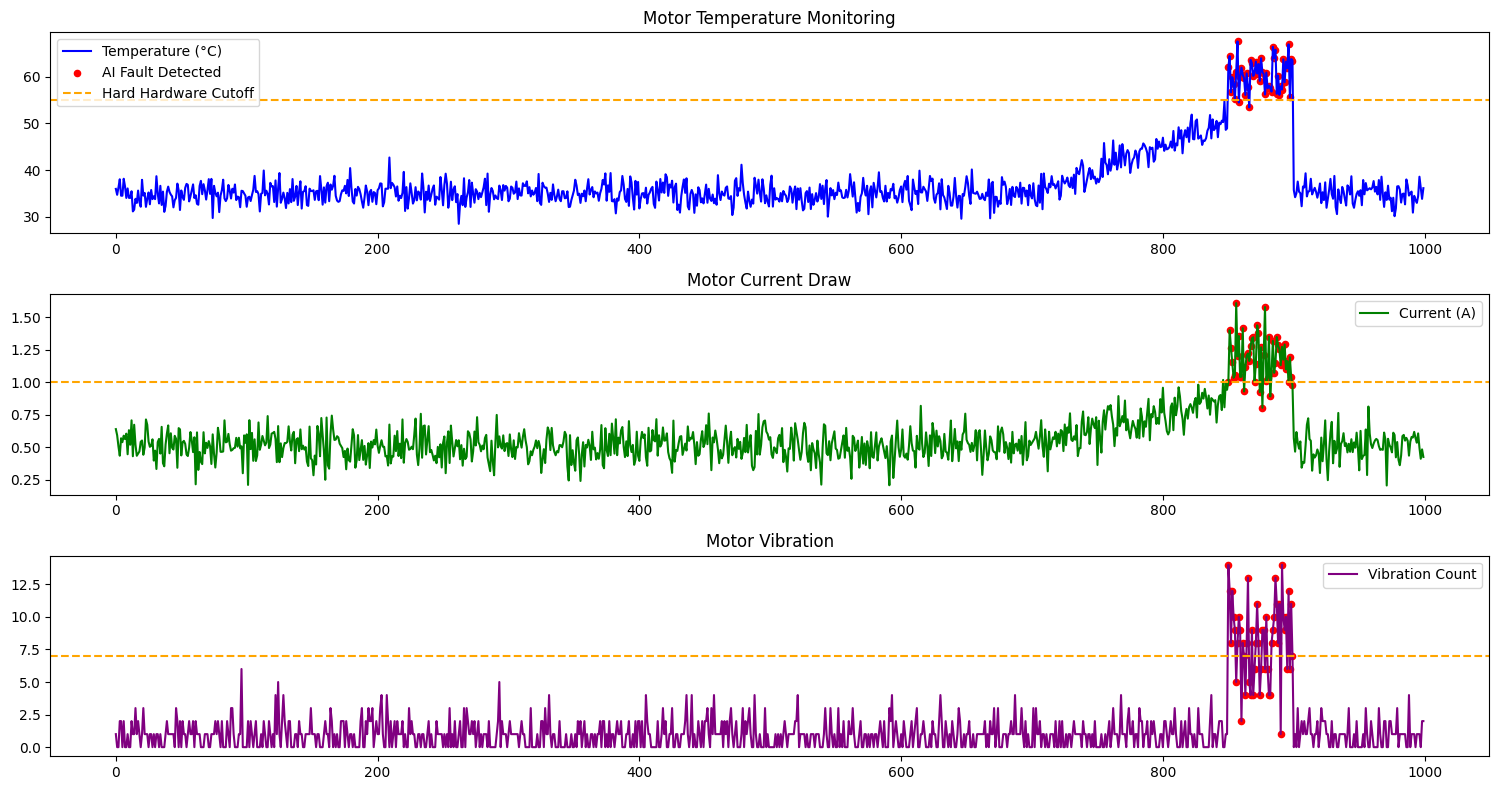


--- AI Predictive Maintenance Report ---
Total time steps analyzed: 1000
Anomalous states predicted proactively by AI: 50


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 1. SIMULATE MOTOR SENSOR DATA
np.random.seed(42)
time_steps = np.arange(1000)

# Normal conditions
temperature = np.random.normal(35, 2, 1000)
current = np.random.normal(0.5, 0.1, 1000)
vibration = np.random.poisson(1, 1000)

# Creeping anomalies (Degradation Phase)
temperature[700:850] += np.linspace(0, 15, 150)
current[700:850] += np.linspace(0, 0.4, 150)

# Hard faults
temperature[850:900] = np.random.normal(60, 3, 50)
current[850:900] = np.random.normal(1.2, 0.2, 50)
vibration[850:900] = np.random.poisson(8, 50)

df = pd.DataFrame({
    'Time': time_steps,
    'Temperature_C': temperature,
    'Current_A': current,
    'Vibration_Count': vibration
})

# 2. PREPROCESS DATA
features = ['Temperature_C', 'Current_A', 'Vibration_Count']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. TRAIN THE ISOLATION FOREST AI
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
model.fit(X_scaled)
df['Anomaly'] = model.predict(X_scaled)

# 4. VISUALIZE THE RESULTS
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(df['Time'], df['Temperature_C'], label='Temperature (°C)', color='blue')
plt.scatter(df[df['Anomaly'] == -1]['Time'], df[df['Anomaly'] == -1]['Temperature_C'], color='red', label='AI Fault Detected', s=20)
plt.axhline(y=55, color='orange', linestyle='--', label='Hard Hardware Cutoff')
plt.legend(); plt.title('Motor Temperature Monitoring')

plt.subplot(3, 1, 2)
plt.plot(df['Time'], df['Current_A'], label='Current (A)', color='green')
plt.scatter(df[df['Anomaly'] == -1]['Time'], df[df['Anomaly'] == -1]['Current_A'], color='red', s=20)
plt.axhline(y=1.0, color='orange', linestyle='--')
plt.legend(); plt.title('Motor Current Draw')

plt.subplot(3, 1, 3)
plt.plot(df['Time'], df['Vibration_Count'], label='Vibration Count', color='purple')
plt.scatter(df[df['Anomaly'] == -1]['Time'], df[df['Anomaly'] == -1]['Vibration_Count'], color='red', s=20)
plt.axhline(y=7, color='orange', linestyle='--')
plt.legend(); plt.title('Motor Vibration')

plt.tight_layout(); plt.show()

print("\n--- AI Predictive Maintenance Report ---")
print(f"Total time steps analyzed: {len(df)}")
print(f"Anomalous states predicted proactively by AI: {len(df[df['Anomaly'] == -1])}")